# Prerequisites

- Technical
    - **Python programming skills**
    - **Numpy skills**: vectorization to avoid loops, masking & indexing, broadcasting...
- Theoretical
    - **Distance Metrics**: familiarity with the Euclidean distance formula (which we've covered in the KNN notebook).

    - **Iterative Optimization**: A conceptual grasp of iterative refinement, where the model improves its internal representation (centroid positions) through repeated cycles.

    - **Initialization Sensitivity**: Awareness of why centroid initialization (e.g., KMeans++) is critical to avoid local minima and ensuring faster convergence.

# Introduction

## 1. What are clustering algorithms?

**Clustering** is a fundamental subfield in unsupervised machine learning, in which the goal is to partition and regroup unlabled data points into distinct crowds/collections called **Clusters** using shared features. This goal is achieved through **maximizing** similarities within a cluster and **minimizing** similarities between groups. The first algorithm we're going to cover in the **Clustering** part is **KMeans**, so in the next sections we're going to discover what it is, problems it solves, how it works and a concrete implementation provided in the `src/` folder.

## 2. What is KMeans Clustering?

**KMeans** is considered as a **Centroid-Based Clustering Algorithm**, this type of clustering groups unsupervised algorithms that group unlabled data points arround central points called **Centroids**, these data points are assigned to the nearest centroid in order to minimize intra-cluster variance which means the amount of dispertion of these data points arround their assigned central point.


## 3. Real-World applications

- **Customer Segmentation**: Businesses analyze spending habits, demographics, and site activity to group customers.
- **Anomaly & Fraud Detection**: Banks use K-Means to identify unusual transactions or anomalies.
- **Document Categorization**: Natural Language Processing (NLP) applications use K-Means to group similar documents together based on word frequencies and themes
- **Inventory & Logistics Management**: grouping similar data points—such as warehouses, SKUs, or customer orders—allowing managers to implement tailored operational strategies.

## 4. When vs When not to use

| Use When | Avoid When |
| --- | --- |
| Speed and scalability is needed: processing massive datasets with millions of samples. | Outliers and Noise: noisy data drastically affects K-Means because it updates cluster cluster centers based on the mean which can cause false assignments. |
| Speed of inference is needed: once trained, it assigns unseen data to clusters by calculating the minimal distance to existing centroids. | Unordinary cluster shapes: it becomes hard for KMeans to capture complex, non-linear patterns because it relies on Euclidean distance |
| `K` is known: when you already have a predefined domain-specific target for how many clusters you need. | `K` not known: determining the optimal number of clusters requires guessing if the data's natural grouping is not known. |

# KMeans Algorithm

## 1. Mathematical formulation

Given a set of $n$ samples each sample $x_i$ is a $d$-dimentional vector $\{x_1, x_2, \dots, x_n/ x_i \in \mathbb{R}^{n, d}\}$, KMeans clustering aims find $k \le n$ centroids $\{\mu_1, \dots, \mu_k\}$ to minimize the within-cluster sum of squares (WCSS/Inertia), which can be formulated as follows:

$$argmin_{S}\sum_{i=1}^k\sum_{x \in S_i}{\lVert x - \mu_i\rVert^2} = argmin_{S}\sum_{i=1}^k|S_i| \cdot Var(S_i)$$

$S = \{S_1, \dots, S_k\}$: set of partitionned sets using k centroids

$S_i$: set of points belonging to centroid $\mu_i$

$|S_i|$: cardinality of the set $S_i$

$x$: data point from $S_i$

$Var(S_i)$: variance of the set $S_i$


## 2. Algorithm

1. Centroid initialization
   - Randomly select k data points from the dataset as initial centroids.

2. Repeat for a number of iterations or until convergence:
   a. Assignment step:
      - For each data point in the dataset:
        i.  Calculate the distance between the data point and each centroid.
        ii. Assign the data point to the nearest centroid.
   
   b. Update step:
      - For each centroid:
        i.  Calculate the new centroid by taking the mean of all data points assigned to it.

3. Convergence criteria:
   - Check if the centroids have stopped moving (i.e., the changes in centroid positions are below a certain threshold).
   - If centroids have converged, terminate the algorithm.
   - If not, repeat steps 2a and 2b.


This is the Naive KMeans approach, and that's because of the initialization step where we choose random points from the dataset as centroids, this could cause two main problems other than the problems mentioned in the `When not to use` section:

- **Local Optima**: it can get stuck in suboptimal arrangements. Random starting centroids mean the algorithm may converge on a local minimum rather than the true global minimum for cluster variance.
- **Inconsistent Results**: Running the algorithm multiple times on the exact same dataset can yield completely different clusters because of the random starting positions


## 3. KMeans++ Initialization

Now to resolve the issues with the naive approach stated in the section before, we're going to change the way we initialize our centroids to the **KMeans++ Initialization** approach:

1. Select a random data point from the dataset as a first centroid.
2. for each remaining centroid repeat the following steps:
   i. for each data point in the dataset, compute its euclidean distance to the nearest already selected centroid $D(x)^2$.
   ii. Choose the next centroid from the remaining data points randomly, using a probability distribution proportional to $D(x)^2$. This          sampling technique ensures that points far from established centroids have a higher chance of being selected.


Applying this small but smart optimization is going to:

- Ensure well-separated starting points and prevent centroids from crowding together.
- Guarantee faster convergence
- Have far better stability than the naive approach.

## 4. Choosing the optimal number of clusters `K`

Like we've discussed before, one of the weak points of KMeans is that we don't know the optimal `K` value, that's why in this section we're going to go through two heuristics to find the optimal point between fit and model complexity:

### Elbow method: Quick intuitive baseline

The core idea of this method is to:
- measure total Within-Cluster Sum of Squares (WCSS) across $K$ values.
- Plot WCSS vs. $K$. Choose the "elbow" point—the which is the sharp bend where adding more clusters yields diminishing returns.

NOTE: the first code cell after this section shows how to do this in code.

### Silhouette Analysis: Best for Evaluating cluster separation and boundary overlap

- Measures how similar an instance is to its own cluster (cohesion) versus other clusters (separation), scored from -1 to +1.
- Calculate average Silhouette Scores across a range of $k$. We choose $k$ with the highest average score.

For each data point $x_i \in S_i$ we define the Silhouette score as this:

$$
s(x_i) = \begin{cases}
  1-\frac{a(x_i)}{b(x_i)}, & \mbox{ if } a(x_i) < b(x_i) \\
  0,  & \mbox{if } a(x_i) = b(x_i) \\
  \frac{b(x_i)}{a(x_i)}-1, & \mbox{ if } a(x_i) > b(x_i) \\
\end{cases}
$$

or:
$$s(x_i) = \frac{b(x_i) - a(x_i)}{max(a(x_i), b(x_i))}, \mbox{ if } |S_i| > 1$$
and:
$$s(x_i) = 0 \mbox{ if } |S_i| = 1$$


$$a(x_i) = \frac{1}{|S_j| - 1 \cdot \sum_{j \in S_j, i \neq j}d(x_i, x_j)}$$
$$b(x_i) = min_{j \neq i}\frac{1}{|S_j|}\sum_{}d(x_i, l)$$

Where:

$a(x_i)$: average distance between $x_i$ and all other points in the same cluster

$b(x_i)$: average distance between $x_i$ and the closest cluster that i doesn't belong to

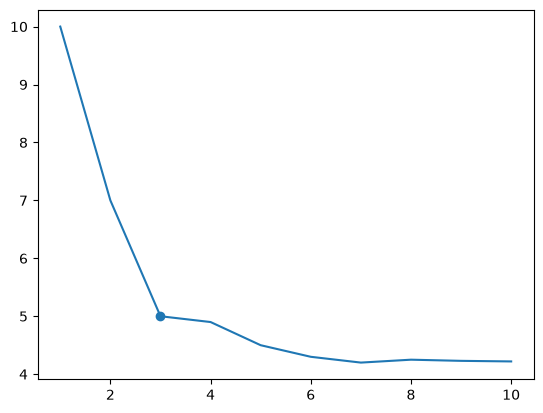

In [49]:
# we define our range of k as x and the WCSS measure for that k as y
x = np.arange(1, 11)
y = [10, 7, 5, 4.9, 4.5, 4.3, 4.2, 4.25, 4.23, 4.22]

# calculate the first derivative
dy_dx = np.gradient(y, x)
# calculate the second derivative
d2y_dx2 = np.gradient(dy_dx, x)
# Use the derivatives to calculate the curvature kappa
curvature = np.abs(d2y_dx2) / (1 + dy_dx**2)**(1.5)

# Extract the point with maximum kappa and that should be the elbow point for this example
elbow_index = np.argmax(curvature)

plt.scatter(x[elbow_index], y[elbow_index])
plt.plot(x, y)

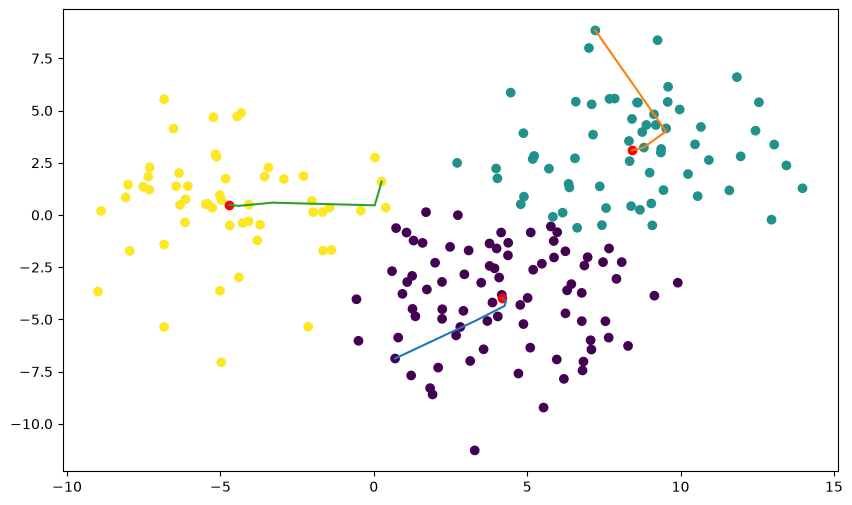

In [42]:
from ml_from_scratch.clustering.kmeans import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

n_samples = 200
X, y = make_blobs(n_samples=n_samples, centers=4, n_features=2, random_state=123, cluster_std=2.5)

k = 3
model = KMeans(k=k, max_iter=200, save_centroid_updates=True)
model.fit(X)

plt.figure(figsize=(10, 6))
feature_0 = X[:, 0]
feature_1 = X[:, 1]

for j in range(k):
    trajectory = model.centroid_updates[:, j, :]
    
    plt.plot(trajectory[:, 0], trajectory[:, 1])
    
plt.scatter(feature_0, feature_1, c=model.transform(X))
plt.scatter(model.centroids[:, 0], model.centroids[:, 1], color='red')

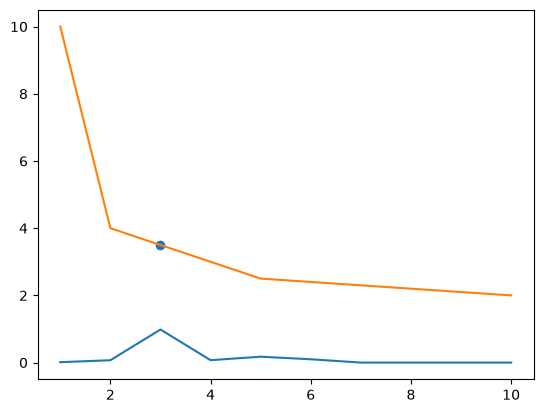

In [41]:
import numpy as np


x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([10, 4, 3.5, 3, 2.5, 2.4, 2.3, 2.2, 2.1, 2])

dy_dx = np.gradient(y, x)
d2y_dx2 = np.gradient(dy_dx, x)
curvature = np.abs(d2y_dx2) / (1 + dy_dx**2)**(1.5)

elbow_index = np.argmax(curvature)

plt.scatter(x[elbow_index], y[elbow_index])

plt.plot(x, curvature)
plt.plot(x, y)